## Profiling of SPH

### Baseline benchmark

In [2]:
import sph

192 ms ± 2.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
791 ms ± 5.26 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
2.34 s ± 35.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.22 s ± 33.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
7.29 s ± 148 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
32.6 s ± 504 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


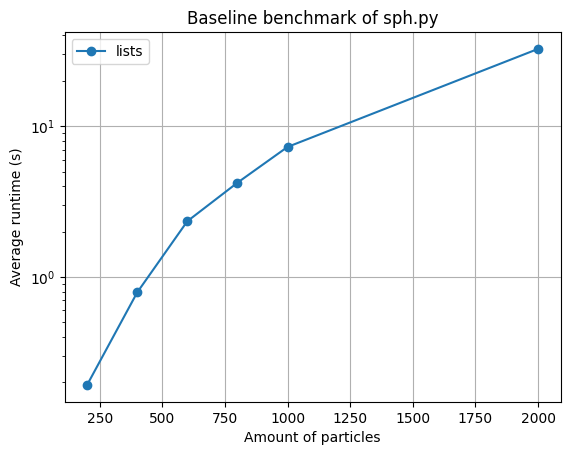

In [3]:
import matplotlib.pyplot as plt

Ns = [200, 400, 600, 800, 1000, 2000] # amount of particles
ts_avg = []


for N in Ns:
    t = %timeit -o sph.main(N)
    ts_avg.append(t.average)


plt.title("Baseline benchmark of sph.py")
plt.plot(Ns, ts_avg, marker='o', label="lists")
plt.xlabel("Amount of particles")
plt.legend()
plt.grid(True)
plt.yscale("log")
plt.ylabel("Average runtime (s)")
plt.show()

### cProfile

In [4]:
# cProfile of functions in sph.py
!python -m cProfile -s cumulative sph.py | awk 'NR==5 || /sph.py/'

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.303    1.303 sph.py:1(<module>)
        1    0.015    0.015    0.776    0.776 sph.py:154(main)
      301    0.098    0.000    0.761    0.003 sph.py:111(getAcc)
      301    0.009    0.000    0.293    0.001 sph.py:79(getDensity)
      301    0.251    0.001    0.251    0.001 sph.py:30(gradW)
      301    0.191    0.001    0.191    0.001 sph.py:13(W)
      602    0.184    0.000    0.185    0.000 sph.py:50(getPairwiseSeparations)
      301    0.000    0.000    0.000    0.000 sph.py:97(getPressure)


#### SnakeViz visualizations of cProfile

In [5]:
# writes cProfile resutls to file (profile.stats)
!python -m cProfile -o profile.stats sph.py

In [6]:
!python -m snakeviz profile.stats --server

snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2FUsers%2Fantonronnquist%2FDesktop%2Foptimizations-of-sph%2Fprofile.stats
Uncaught exception GET /snakeviz/%2FUsers%2Fisakf%2Fdev%2Fkth%2Fhpc%2Foptimizations-of-sph%2Fprofile.stats (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8080', method='GET', uri='/snakeviz/%2FUsers%2Fisakf%2Fdev%2Fkth%2Fhpc%2Foptimizations-of-sph%2Fprofile.stats', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/Users/antonronnquist/Desktop/optimizations-of-sph/env/lib/python3.14/site-packages/snakeviz/main.py", line 28, in get
    s = Stats(profile_name)
  File "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/pstats.py", line 114, in __init__
    self.init(arg)
    ~~~~~~~~~^^^^^
  File "/opt/homebrew/Cellar/python@3.14/3.14.3_1/Frameworks/Python.framework/Versions/3.14/lib/python3.14/pstats.py", line 128, in 

![Snakeviz Of Baseline](./images/snakeviz_baseline.png)

### Line Profiler

In [9]:
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [ ]:
%lprun -f sph.W -f sph.gradW -f sph.getAcc -f sph.getDensity sph.main(1000)

Timer unit: 1e-09 s

Total time: 0.197542 s
File: /Users/antonronnquist/Desktop/optimizations-of-sph/sph.py
Function: W at line 13

Line #      Hits         Time  Per Hit   % Time  Line Contents
    13                                           def W(x, y, z, h):
    14                                               """
    15                                               Gausssian Smoothing kernel (3D)
    16                                                   x     is a vector/matrix of x positions
    17                                                   y     is a vector/matrix of y positions
    18                                                   z     is a vector/matrix of z positions
    19                                                   h     is the smoothing length
    20                                                   w     is the evaluated smoothing function
    21                                               """
    22                                           
    23     

### Memory Profiler

In [20]:
!mprof run sph.py

mprof: Sampling memory every 0.1s
running new process
running as a Python program...


Using last profile data.


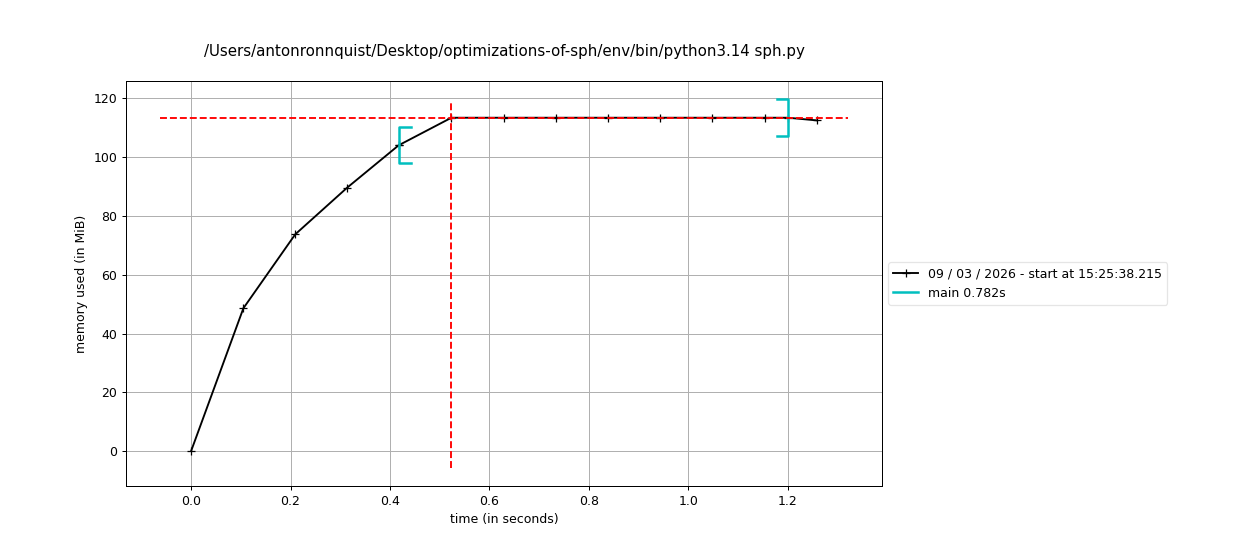

In [21]:
!mprof plot -o mprof_sph_plot.png

from IPython.display import Image
Image(filename='mprof_sph_plot.png')

In [15]:
!python -m memory_profiler sph.py

/Users/antonronnquist/Desktop/optimizations-of-sph/env/lib/python3.14/site-packages/memory_profiler.py:752: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if iscoroutinefunction(func):
Filename: sph.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    12  116.891 MiB 35177.594 MiB         301   @profile
    13                                         def W(x, y, z, h):
    14                                             """
    15                                             Gausssian Smoothing kernel (3D)
    16                                                 x     is a vector/matrix of x positions
    17                                                 y     is a vector/matrix of y positions
    18                                                 z     is a vector/matrix of z positions
    19                                                 h     is the smoothing length
    

### Cython optimization

In [27]:
%%cython -a

import numpy as np
cimport numpy as np
from scipy.special import gamma
from libc.math cimport sqrt, exp, pow, M_PI

cdef inline double W_cython(double dx, double dy, double dz, double h) nogil:
    cdef double r2 = dx*dx + dy*dy + dz*dz
    # Använder C:s exp och sqrt istället för NumPys
    return (1.0 / (h * sqrt(M_PI)))**3 * exp(-r2 / (h*h))

cdef void getDensity_cython(double[:, :] pos, double m, double h, double[:] rho) nogil:
    cdef int N = pos.shape[0]
    cdef int i, j
    cdef double dx, dy, dz
    
    for i in range(N):
        rho[i] = 0.0
        for j in range(N):
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]
            dz = pos[i, 2] - pos[j, 2]
            rho[i] += m * W_cython(dx, dy, dz, h)

cdef void getAcc_cython(double[:, :] pos, double[:, :] vel, double m, double h, double k, double n_poly, double lmbda, double nu, double[:] rho, double[:] P, double[:, :] acc) nogil:
    cdef int N = pos.shape[0]
    cdef int i, j
    cdef double dx, dy, dz, r2, n_val, wx, wy, wz, pressure_term
    
    getDensity_cython(pos, m, h, rho)
    
    for i in range(N):
        P[i] = k * pow(rho[i], 1.0 + 1.0/n_poly)
        
    for i in range(N):
        acc[i, 0] = 0.0
        acc[i, 1] = 0.0
        acc[i, 2] = 0.0
        
        for j in range(N):
            dx = pos[i, 0] - pos[j, 0]
            dy = pos[i, 1] - pos[j, 1]
            dz = pos[i, 2] - pos[j, 2]
            
            r2 = dx*dx + dy*dy + dz*dz
            n_val = -2.0 * exp(-r2 / (h*h)) / (pow(h, 5) * pow(M_PI, 1.5))
            wx = n_val * dx
            wy = n_val * dy
            wz = n_val * dz
            
            pressure_term = (P[i] / (rho[i]*rho[i])) + (P[j] / (rho[j]*rho[j]))
            
            acc[i, 0] -= m * pressure_term * wx
            acc[i, 1] -= m * pressure_term * wy
            acc[i, 2] -= m * pressure_term * wz
            
        acc[i, 0] += -lmbda * pos[i, 0] - nu * vel[i, 0]
        acc[i, 1] += -lmbda * pos[i, 1] - nu * vel[i, 1]
        acc[i, 2] += -lmbda * pos[i, 2] - nu * vel[i, 2]

def run_sph_cython(int N=400):
    cdef double t = 0.0
    cdef double tEnd = 12.0
    cdef double dt = 0.04
    cdef double M = 2.0
    cdef double R = 0.75
    cdef double h = 0.1
    cdef double k = 0.1
    cdef double n_poly = 1.0
    cdef double nu = 1.0

    np.random.seed(42)

    cdef double lmbda = (2 * k * (1 + n_poly) * np.pi ** (-3 / (2 * n_poly)) * (M * gamma(5 / 2 + n_poly) / R**3 / gamma(1 + n_poly)) ** (1 / n_poly) / R**2)
    cdef double m = M / N
    
    pos_np = np.random.randn(N, 3).astype(np.float64)
    vel_np = np.zeros((N, 3), dtype=np.float64)
    acc_np = np.zeros((N, 3), dtype=np.float64)
    rho_np = np.zeros(N, dtype=np.float64)
    P_np = np.zeros(N, dtype=np.float64)

    cdef double[:, :] pos = pos_np
    cdef double[:, :] vel = vel_np
    cdef double[:, :] acc = acc_np
    cdef double[:] rho = rho_np
    cdef double[:] P = P_np

    cdef int Nt = int(np.ceil(tEnd / dt))
    cdef int i, step

    getAcc_cython(pos, vel, m, h, k, n_poly, lmbda, nu, rho, P, acc)

    for step in range(Nt):
        for i in range(N):
            vel[i, 0] += acc[i, 0] * dt / 2.0
            vel[i, 1] += acc[i, 1] * dt / 2.0
            vel[i, 2] += acc[i, 2] * dt / 2.0

        for i in range(N):
            pos[i, 0] += vel[i, 0] * dt
            pos[i, 1] += vel[i, 1] * dt
            pos[i, 2] += vel[i, 2] * dt

        getAcc_cython(pos, vel, m, h, k, n_poly, lmbda, nu, rho, P, acc)

        for i in range(N):
            vel[i, 0] += acc[i, 0] * dt / 2.0
            vel[i, 1] += acc[i, 1] * dt / 2.0
            vel[i, 2] += acc[i, 2] * dt / 2.0

        t += dt

    return pos_np, vel_np

### Valdiation

In [29]:
import sph
import numpy as np

N = 400
pos_py, vel_py = sph.main(N)
pos_cy, vel_cy = run_sph_cython(N)

pos_match = np.allclose(pos_py, pos_cy, atol=1e-8)
vel_match = np.allclose(vel_py, vel_cy, atol=1e-8)

print("Validation")
print(f"Position are the same {pos_match}")
print(f"velocity is same {vel_match}")

if not pos_match:
    print(f"biggest difference {np.max(np.abs(pos_py - pos_cy))}")

Validation
Position are the same True
velocity is same True


### Comparison Time and peak memory

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


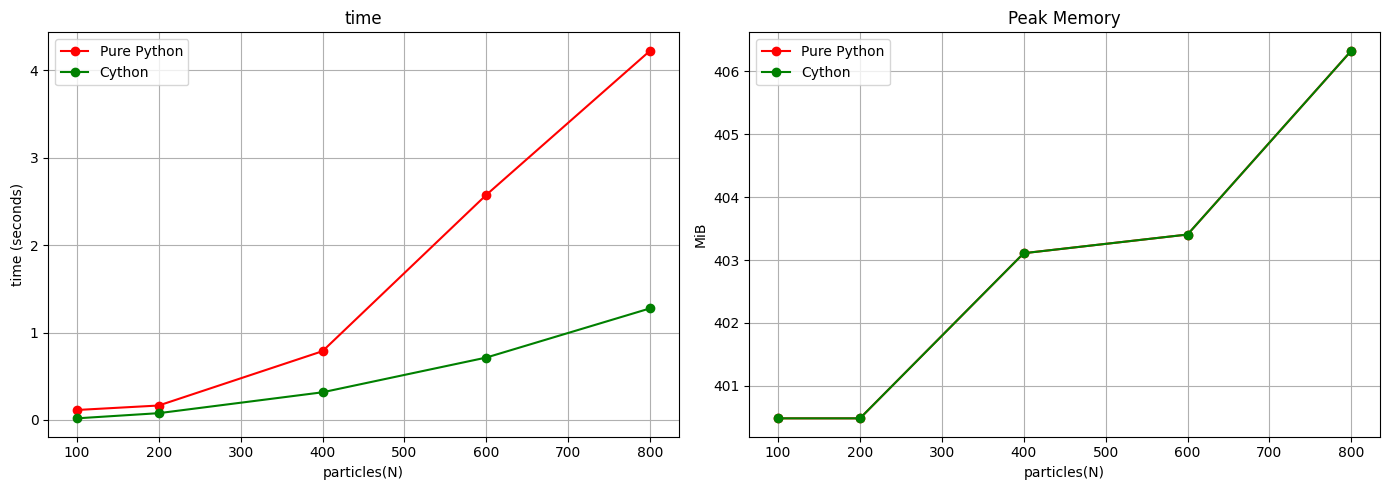

In [33]:
import time
import matplotlib.pyplot as plt
%load_ext memory_profiler

Ns = [100, 200, 400, 600, 800] 
time_py, time_cy = [], []
mem_py, mem_cy = [], []

for N in Ns:
    t0 = time.time()
    sph.main(N)
    time_py.append(time.time() - t0)
    
    res_py = %memit -o -q sph.main(N)
    mem_py.append(res_py.mem_usage[0])
    
    t0 = time.time()
    run_sph_cython(N)
    time_cy.append(time.time() - t0)
    
    res_cy = %memit -o -q run_sph_cython(N)
    mem_cy.append(res_cy.mem_usage[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(Ns, time_py, marker='o', color='red', label='Pure Python')
ax1.plot(Ns, time_cy, marker='o', color='green', label='Cython')
ax1.set_title('time')
ax1.set_xlabel('particles(N)')
ax1.set_ylabel('time (seconds)')
ax1.legend()
ax1.grid(True)

ax2.plot(Ns, mem_py, marker='o', color='red', label='Pure Python')
ax2.plot(Ns, mem_cy, marker='o', color='green', label='Cython')
ax2.set_title('Peak Memory')
ax2.set_xlabel('particles(N)')
ax2.set_ylabel('MiB')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Proving no increment in memory

In [55]:
!python -m memory_profiler prove_memory.py

/Users/antonronnquist/Desktop/optimizations-of-sph/env/lib/python3.14/site-packages/memory_profiler.py:752: DeprecationWarning: 'asyncio.iscoroutinefunction' is deprecated and slated for removal in Python 3.16; use inspect.iscoroutinefunction() instead
  if iscoroutinefunction(func):
run sph.py
Filename: prove_memory.py

Line #    Mem usage    Increment  Occurrences   Line Contents
     5    106.1 MiB    106.1 MiB           1   @profile
     6                                         def test_old_python():
     7    106.1 MiB      0.0 MiB           1       print("run sph.py")
     8    133.7 MiB     27.6 MiB           1       sph.main(400)


run cython_sph.py
Filename: prove_memory.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    10    133.7 MiB    133.7 MiB           1   @profile
    11                                         def test_new_cython():
    12    133.7 MiB      0.0 MiB           1       print("run cython_sph.py")
    13    133.8 MiB      0.0 MiB        